In [13]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score

In [14]:
claimants_df=pd.read_csv("claimants.csv")
claimants_df

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [15]:
#Basic Eda

claimants_df.shape

(1340, 7)

In [16]:
claimants_df.columns

Index(['CASENUM', 'ATTORNEY', 'CLMSEX', 'CLMINSUR', 'SEATBELT', 'CLMAGE',
       'LOSS'],
      dtype='str')

In [17]:
claimants_df.info

<bound method DataFrame.info of       CASENUM  ATTORNEY  CLMSEX  CLMINSUR  SEATBELT  CLMAGE    LOSS
0           5         0     0.0       1.0       0.0    50.0  34.940
1           3         1     1.0       0.0       0.0    18.0   0.891
2          66         1     0.0       1.0       0.0     5.0   0.330
3          70         0     0.0       1.0       1.0    31.0   0.037
4          96         1     0.0       1.0       0.0    30.0   0.038
...       ...       ...     ...       ...       ...     ...     ...
1335    34100         1     0.0       1.0       0.0     NaN   0.576
1336    34110         0     1.0       1.0       0.0    46.0   3.705
1337    34113         1     1.0       1.0       0.0    39.0   0.099
1338    34145         0     1.0       0.0       0.0     8.0   3.177
1339    34153         1     1.0       1.0       0.0    30.0   0.688

[1340 rows x 7 columns]>

In [18]:
claimants_df.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [19]:
claimants_df.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

In [20]:
claimants_df.describe()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
count,1340.000000,1340.000000,1328.000000,1299.000000,1292.000000,1151.000000,1340.000000
mean,11202.001493,0.488806,0.558735,0.907621,0.017028,28.414422,3.806307
std,9512.750796,0.500061,0.496725,0.289671,0.129425,20.304451,10.636903
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4177.000000,0.000000,0.000000,1.000000,0.000000,9.000000,0.400000
50%,8756.500000,0.000000,1.000000,1.000000,0.000000,30.000000,1.069500
75%,15702.500000,1.000000,1.000000,1.000000,0.000000,43.000000,3.781500
max,34153.000000,1.000000,1.000000,1.000000,1.000000,95.000000,173.604000


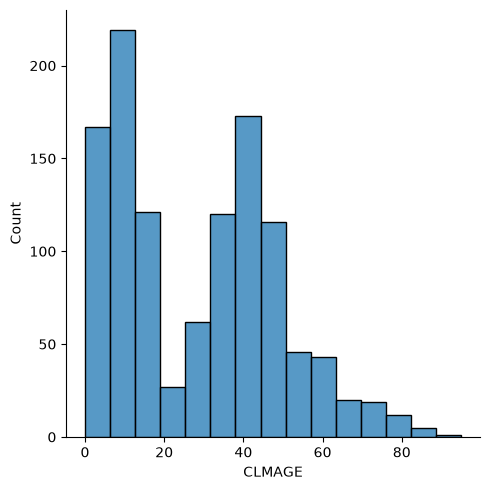

In [21]:
sns.displot(data=claimants_df["CLMAGE"])
plt.show()

In [22]:
# Making null values 0

In [23]:
claimants_df["CLMSEX"]=claimants_df["CLMSEX"].fillna(claimants_df["CLMSEX"].mode()[0])
claimants_df["CLMINSUR"]=claimants_df["CLMINSUR"].fillna(claimants_df["CLMINSUR"].mode()[0])
claimants_df["SEATBELT"]=claimants_df["SEATBELT"].fillna(claimants_df["SEATBELT"].mode()[0])
claimants_df.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX        0
CLMINSUR      0
SEATBELT      0
CLMAGE      189
LOSS          0
dtype: int64

In [24]:
claimants_df["CLMAGE"]=claimants_df["CLMAGE"].fillna(claimants_df["CLMAGE"].median())
claimants_df.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [25]:
# 18/8

In [26]:
claimants_df["ATTORNEY"].value_counts()

ATTORNEY
0    685
1    655
Name: count, dtype: int64

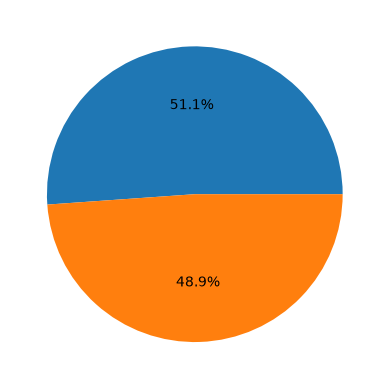

In [27]:
plt.pie(claimants_df["ATTORNEY"].value_counts(),autopct='%1.1f%%')

# Feature selection

In [28]:
x=claimants_df.drop(labels=["CASENUM","ATTORNEY"],axis=1)
y=claimants_df["ATTORNEY"]

# Train-test split

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=32,stratify=y)

In [30]:
x_train.shape

(1072, 5)

In [31]:
x_test.shape

(268, 5)

In [32]:
y_train.shape

(1072,)

In [33]:
y_test.shape

(268,)

# Model Building

In [34]:
model=LogisticRegression(max_iter=100000)

# Model Training

In [35]:
model.fit(x_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",100000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is

# Model Testing

In [36]:
y_train_pred=model.predict(x_train)
y_test_pred=model.predict(x_test)

In [37]:
accuracy_score(y_train,y_train_pred)

0.7117537313432836

In [38]:
accuracy_score(y_test,y_test_pred)

0.6791044776119403

# (Outliers cannot be removed because this data is categorical data)

# Confusion matrix

In [39]:
confusion_matrix(y_test,y_test_pred)

array([[ 82,  55],
       [ 31, 100]])

# Precision -----> Predicted positives how many actually correct?

In [40]:
precision_score(y_test,y_test_pred)

0.6451612903225806

# Recall -----> Out of all actual positives how many model find?

In [41]:
recall_score(y_test,y_test_pred)

0.7633587786259542

# F1 score -----> It is the harmonic mean of precision and recall.It ranges from 0 (worst) to 1 (best).

In [42]:
f1_score(y_test,y_test_pred)

0.6993006993006993

# Hyperparameter tuning

# Grid search CV

In [43]:
from sklearn.model_selection import GridSearchCV

In [44]:
GCV=GridSearchCV(estimator=model,param_grid={"C":[0.0001,0.01,0.1,1,10,100],"solver":["lbfgs","sag","saga","liblinear","newton-cg"]},cv=5)

In [45]:
GCV.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...x_iter=100000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.0001, 0.01, ...], 'solver': ['lbfgs', 'sag', ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information

In [46]:
GCV.best_params_

{'C': 1, 'solver': 'lbfgs'}

# Decision Tree

In [47]:
from sklearn.tree import DecisionTreeClassifier

In [48]:
# Model Buliding

In [49]:
DT_model=DecisionTreeClassifier()

In [50]:
# Model Training

In [51]:
DT_model.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [52]:
# Model testing

In [53]:
Y_train_pred=DT_model.predict(x_train)
Y_test_pred=DT_model.predict(x_test)

In [54]:
# Model Evalution

In [55]:
accuracy_score(y_train,Y_train_pred)

0.9934701492537313

In [56]:
accuracy_score(y_test,Y_test_pred)

0.5708955223880597

In [57]:
from sklearn import tree

[Text(0.4209039135514019, 0.9791666666666666, 'x[4] <= 1.04\ngini = 0.5\nsamples = 1072\nvalue = [548, 524]'),
 Text(0.17413843457943926, 0.9375, 'x[3] <= 7.5\ngini = 0.403\nsamples = 519\nvalue = [145, 374]'),
 Text(0.29752117406542056, 0.9583333333333333, 'True  '),
 Text(0.08200934579439252, 0.8958333333333334, 'x[4] <= 0.624\ngini = 0.491\nsamples = 127\nvalue = [55, 72]'),
 Text(0.04439252336448598, 0.8541666666666666, 'x[1] <= 0.5\ngini = 0.467\nsamples = 105\nvalue = [39, 66]'),
 Text(0.026168224299065422, 0.8125, 'x[3] <= 4.5\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.022429906542056073, 0.7708333333333334, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.029906542056074768, 0.7708333333333334, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.06261682242990654, 0.8125, 'x[4] <= 0.422\ngini = 0.459\nsamples = 101\nvalue = [36, 65]'),
 Text(0.037383177570093455, 0.7708333333333334, 'x[4] <= 0.112\ngini = 0.48\nsamples = 75\nvalue = [30, 45]'),
 Text(0.01495327102

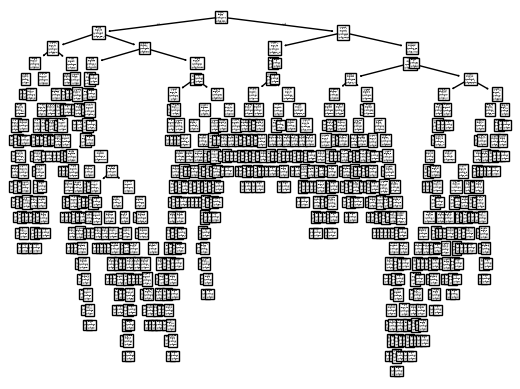

In [58]:
tree.plot_tree(DT_model)

# Overfitting------> Training High accuracy, Testing low accuracy

In [71]:
DT_modell=DecisionTreeClassifier(random_state=32)
DT_modell.fit(x_train,y_train)
Y_train_pred=DT_modell.predict(x_train)
Y_test_pred=DT_modell.predict(x_test)
print(accuracy_score(y_train,Y_train_pred))
print(accuracy_score(y_test,Y_test_pred))

1.0
1.0


In [72]:
DT_modell=DecisionTreeClassifier(max_depth=5)
DT_modell.fit(x_train,y_train)
Y_train_pred=DT_modell.predict(x_train)
Y_test_pred=DT_modell.predict(x_test)
print(accuracy_score(y_train,Y_train_pred))
print(accuracy_score(y_test,Y_test_pred))

1.0
1.0


In [61]:
DT_model1=DecisionTreeClassifier(max_depth=7)
DT_model1.fit(x_train,y_train)
Y_train_pred=DT_model1.predict(x_train)
Y_test_pred=DT_model1.predict(x_test)
print(accuracy_score(y_train,Y_train_pred))
print(accuracy_score(y_test,Y_test_pred))

0.7910447761194029
0.6940298507462687


In [62]:
from sklearn import tree

[Text(0.4964080459770115, 0.9375, 'x[4] <= 1.04\ngini = 0.5\nsamples = 1072\nvalue = [548, 524]'),
 Text(0.2672413793103448, 0.8125, 'x[3] <= 7.5\ngini = 0.403\nsamples = 519\nvalue = [145, 374]'),
 Text(0.3818247126436781, 0.875, 'True  '),
 Text(0.15229885057471265, 0.6875, 'x[4] <= 0.624\ngini = 0.491\nsamples = 127\nvalue = [55, 72]'),
 Text(0.06321839080459771, 0.5625, 'x[1] <= 0.5\ngini = 0.467\nsamples = 105\nvalue = [39, 66]'),
 Text(0.022988505747126436, 0.4375, 'x[3] <= 4.5\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.011494252873563218, 0.3125, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.034482758620689655, 0.3125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.10344827586206896, 0.4375, 'x[4] <= 0.422\ngini = 0.459\nsamples = 101\nvalue = [36, 65]'),
 Text(0.05747126436781609, 0.3125, 'x[4] <= 0.112\ngini = 0.48\nsamples = 75\nvalue = [30, 45]'),
 Text(0.034482758620689655, 0.1875, 'x[3] <= 5.5\ngini = 0.416\nsamples = 44\nvalue = [13, 31]'),
 Text(0.0

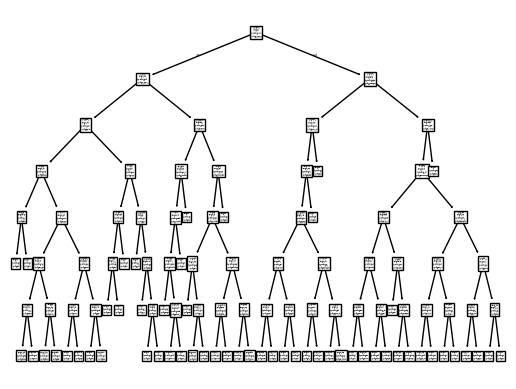

In [63]:
tree.plot_tree(DT_model1)

In [64]:
from sklearn.model_selection import GridSearchCV

In [65]:
GCV=GridSearchCV(estimator=DT_modell,param_grid={"criterion":['gini',"entropy","log_less"],"max_depth":[1,2,3,4,5,6,7,8,9,10]},cv=5)

In [66]:
GCV.fit(x_train,y_train)

C:\Users\RITHIKA.R\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
50 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\RITHIKA.R\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\RITHIKA.R\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...r(max_depth=5)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of infor

In [67]:
GCV.best_params_

{'criterion': 'entropy', 'max_depth': 3}

In [68]:
y_train=GCV.predict(x_train)
y_test=GCV.predict(x_test)

In [69]:
accuracy_score(y_train,Y_train_pred)

0.9225746268656716

In [70]:
accuracy_score(y_test,Y_test_pred)

0.9029850746268657